In [2]:
%pip install -U transformers accelerate datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 97.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 41.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 72.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
# Import important libraries
import pandas as pd
from datasets import load_dataset 
import transformers
from transformers import BlipProcessor, BlipForImageTextRetrieval,BlipForConditionalGeneration, AutoProcessor
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Resize
import os

import gc
import numpy as np
import pandas as pd
import itertools
from tqdm import tqdm
import albumentations as A
import cv2
import shutil
import json
from PIL import Image
import requests
from matplotlib import pyplot as plt

2025-12-27 06:25:25.498049: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766816725.674368      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766816725.722332      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
import json
import os
from datasets import Dataset

# --- 1) Đường dẫn file JSON và root folder ---
json_file = "/kaggle/input/llm-ct-scan/LLM_Lung_Project/train/train.json"
root = "/kaggle/input/llm-ct-scan/LLM_Lung_Project/train/images"

# --- 2) Đọc file JSON ---
with open(json_file, "r", encoding="utf-8") as f:
    json_data = json.load(f)

print(f"Tổng số mẫu trong JSON: {len(json_data)}")

# --- 3) Chuẩn hóa dữ liệu ---
data = []
for item in json_data:
    img_path = item["image"].replace("\\", "/")
    img_name = os.path.basename(img_path)
    full_path = os.path.join(root, img_name)
    data.append({
        "image": full_path,
        "text": item["text"]
    })

print(f"Tổng số mẫu sau xử lý: {len(data)}")
print(data[0])


Tổng số mẫu trong JSON: 1391
Tổng số mẫu sau xử lý: 1391
{'image': '/kaggle/input/llm-ct-scan/LLM_Lung_Project/train/images/PMC4347543_12995_2015_48_Fig1_HTML.jpg', 'text': 'Contrast enhanced computed tomography revealing Crazy paving patterned diffuse ground glass attenuation with inter/intralobular septal thickening, representing diffuse alveolar damage, both lungs (black arrow).'}


In [3]:
from datasets import Dataset

dataset = Dataset.from_list(data)

Let's check whether the dataset is created correctly:

In [4]:
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 1391
})

Let's take a look at one example:

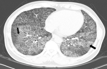

Contrast enhanced computed tomography revealing Crazy paving patterned diffuse ground glass attenuation with inter/intralobular septal thickening, representing diffuse alveolar damage, both lungs (black arrow).


In [5]:
from PIL import Image
from IPython.display import display

example = dataset[0]

# Đọc đường dẫn ảnh
img_path = example["image"]
image = Image.open(img_path).convert("RGB")

width, height = image.size

# Hiển thị ảnh thu nhỏ 30%
display(image.resize((int(0.3*width), int(0.3*height))))

# Hiển thị text
print(example["text"])

Let's check its corresponding caption:

## Create PyTorch Dataset

In [6]:
from torch.utils.data import Dataset

class ImageCaptioningDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        image = Image.open(item["image"]).convert("RGB")

        encoding = self.processor(
            images=image,
            text=item["text"],
            # padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # remove batch dimension
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}

        # Đảm bảo pixel_values có kích thước [C, H, W]
        if encoding['pixel_values'].dim() == 4:
            encoding['pixel_values'] = encoding['pixel_values'].squeeze(0)

        if encoding.get('input_ids') is not None:
             encoding["labels"] = encoding["input_ids"].clone()

        return encoding

In [7]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [25]:
train_dataset = ImageCaptioningDataset(dataset, processor)

Let's check one example of the dataset:

In [26]:
item = train_dataset[0]
for k,v in item.items():
  print(k,v.shape)

pixel_values torch.Size([3, 384, 384])
input_ids torch.Size([42])
attention_mask torch.Size([42])
labels torch.Size([42])


## Create PyTorch DataLoader

In [27]:
from torch.utils.data import DataLoader
from transformers import DataCollatorForSeq2Seq

# Data collator cho dynamic padding
collator = DataCollatorForSeq2Seq(
    tokenizer=processor.tokenizer,
    padding=True,          # padding batch động
    return_tensors="pt"
)

# Dataloader
train_dataloader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collator    # quan trọng
)

In [28]:
batch = next(iter(train_dataloader))
for k,v in batch.items():
  print(k,v.shape)

pixel_values torch.Size([2, 3, 384, 384])
input_ids torch.Size([2, 74])
attention_mask torch.Size([2, 74])
labels torch.Size([2, 74])


Let's check one batch, and do some sanity checks. We can decode the input_ids back into text for instance:

In [29]:
processor.decode(batch["input_ids"][0])

'[CLS] coronal mip image ( maximum intensity projection ; image reconstruction thickness 10 mm ) of high - resolution computed tomographic chest scan ( performed on 160 - slice mdct scanner ; toshiba acquillon ) showing multiple clusters of small centrilobular nodules in bilateral lungs, predominantly in lower lobes. bronchial wall thickening is also evident. [SEP]'

We can "denormalize" the pixel values to get back an image:

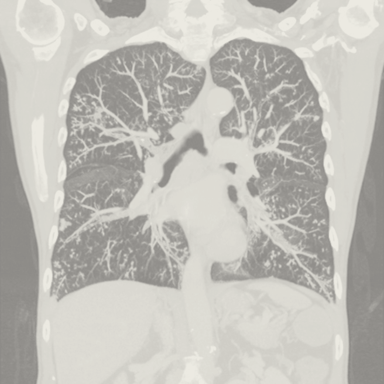

In [30]:
from PIL import Image
import numpy as np

MEAN = np.array([123.675, 116.280, 103.530]) / 255
STD = np.array([58.395, 57.120, 57.375]) / 255

unnormalized_image = (batch["pixel_values"][0].numpy() * np.array(STD)[:, None, None]) + np.array(MEAN)[:, None, None]
unnormalized_image = (unnormalized_image * 255).astype(np.uint8)
unnormalized_image = np.moveaxis(unnormalized_image, 0, -1)
Image.fromarray(unnormalized_image)

## Define model

Next, we instantiate a model. We start from the pre-trained BLIP2-base model (which was already pre-trained on 4 million image-text pairs by Microsoft).

In [31]:

model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

## Dummy forward pass

In [32]:
outputs = model(input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                pixel_values=batch["pixel_values"],
                labels=batch["input_ids"])
outputs.loss

tensor(10.6484, grad_fn=<NllLossBackward0>)

## Train the model

In [33]:
import torch
from tqdm import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.train()

EPOCHS = 35

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")
    epoch_loss = 0

    for batch in tqdm(train_dataloader):

        input_ids = batch["input_ids"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            labels=input_ids
        )

        loss = outputs.loss
        epoch_loss += loss.item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    print(f">>> Average Loss: {epoch_loss / len(train_dataloader):.4f}")

# ===== Lưu model =====
save_path = "/kaggle/working/blip2_finetuned"
model.save_pretrained(save_path)
processor.save_pretrained(save_path)
print(f"✅ Model đã được lưu tại: {save_path}")


===== Epoch 1/35 =====


100%|██████████| 696/696 [03:26<00:00,  3.37it/s]


>>> Average Loss: 3.1810

===== Epoch 2/35 =====


100%|██████████| 696/696 [03:19<00:00,  3.49it/s]


>>> Average Loss: 2.2203

===== Epoch 3/35 =====


...

>>> Average Loss: 0.0858

===== Epoch 34/35 =====


100%|██████████| 696/696 [03:27<00:00,  3.35it/s]


>>> Average Loss: 0.0878

===== Epoch 35/35 =====


100%|██████████| 696/696 [03:29<00:00,  3.32it/s]


>>> Average Loss: 0.0837
✅ Model đã được lưu tại: /kaggle/working/blip2_finetuned


## Inference

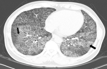

Contrast enhanced computed tomography revealing Crazy paving patterned diffuse ground glass attenuation with inter/intralobular septal thickening, representing diffuse alveolar damage, both lungs (black arrow).


In [39]:
from PIL import Image
from IPython.display import display

example = dataset[0]

# Đọc đường dẫn ảnh
img_path = example["image"]
image = Image.open(img_path).convert("RGB")

width, height = image.size

# Hiển thị ảnh thu nhỏ 30%
display(image.resize((int(0.3*width), int(0.3*height))))

# Hiển thị text
print(example["text"])

In [ ]:
# %pip install sentencepiece

In [ ]:
# from transformers import MarianTokenizer, MarianMTModel

# model_name = "Helsinki-NLP/opus-mt-en-vi"
# trans_tokenizer = MarianTokenizer.from_pretrained(model_name)
# trans_model = MarianMTModel.from_pretrained(model_name).to(device)

In [41]:
# Generate caption
inputs = processor(images=image, return_tensors="pt").to(device)

generated_ids = model.generate(
    pixel_values=inputs["pixel_values"],
    max_length=256,
    num_beams=5,
    no_repeat_ngram_size=2,
    repetition_penalty=1.2,
    early_stopping=True
)

generated_caption = processor.decode(generated_ids[0], skip_special_tokens=True)
print("Caption (English):", generated_caption)

# batch = trans_tokenizer([generated_caption], return_tensors="pt").to(device)
# translated = trans_model.generate(**batch, max_length=256)

# translated_caption = trans_tokenizer.decode(translated[0], skip_special_tokens=True)
# print("Caption (Vietnamese):", translated_caption)

Caption (English): hrct of patient with abpa showing complete left lung collapse due to mucous plug obstruction


# Evaluate

In [42]:
import json
import os
from datasets import Dataset

# --- 1) Đường dẫn file JSON và root folder ---
json_file = "/kaggle/input/llm-ct-scan/LLM_Lung_Project/test/test.json"
root = "/kaggle/input/llm-ct-scan/LLM_Lung_Project/test/images"

# --- 2) Đọc file JSON ---
with open(json_file, "r", encoding="utf-8") as f:
    json_data = json.load(f)

print(f"Tổng số mẫu trong JSON: {len(json_data)}")

# --- 3) Chuẩn hóa dữ liệu ---
data = []
for item in json_data:
    img_path = item["image"].replace("\\", "/")
    img_name = os.path.basename(img_path)
    full_path = os.path.join(root, img_name)
    data.append({
        "image": full_path,
        "text": item["text"]
    })

print(f"Tổng số mẫu sau xử lý: {len(data)}")

test_dataset = Dataset.from_list(data)
test_dataset

Tổng số mẫu trong JSON: 155
Tổng số mẫu sau xử lý: 155


Dataset({
    features: ['image', 'text'],
    num_rows: 155
})

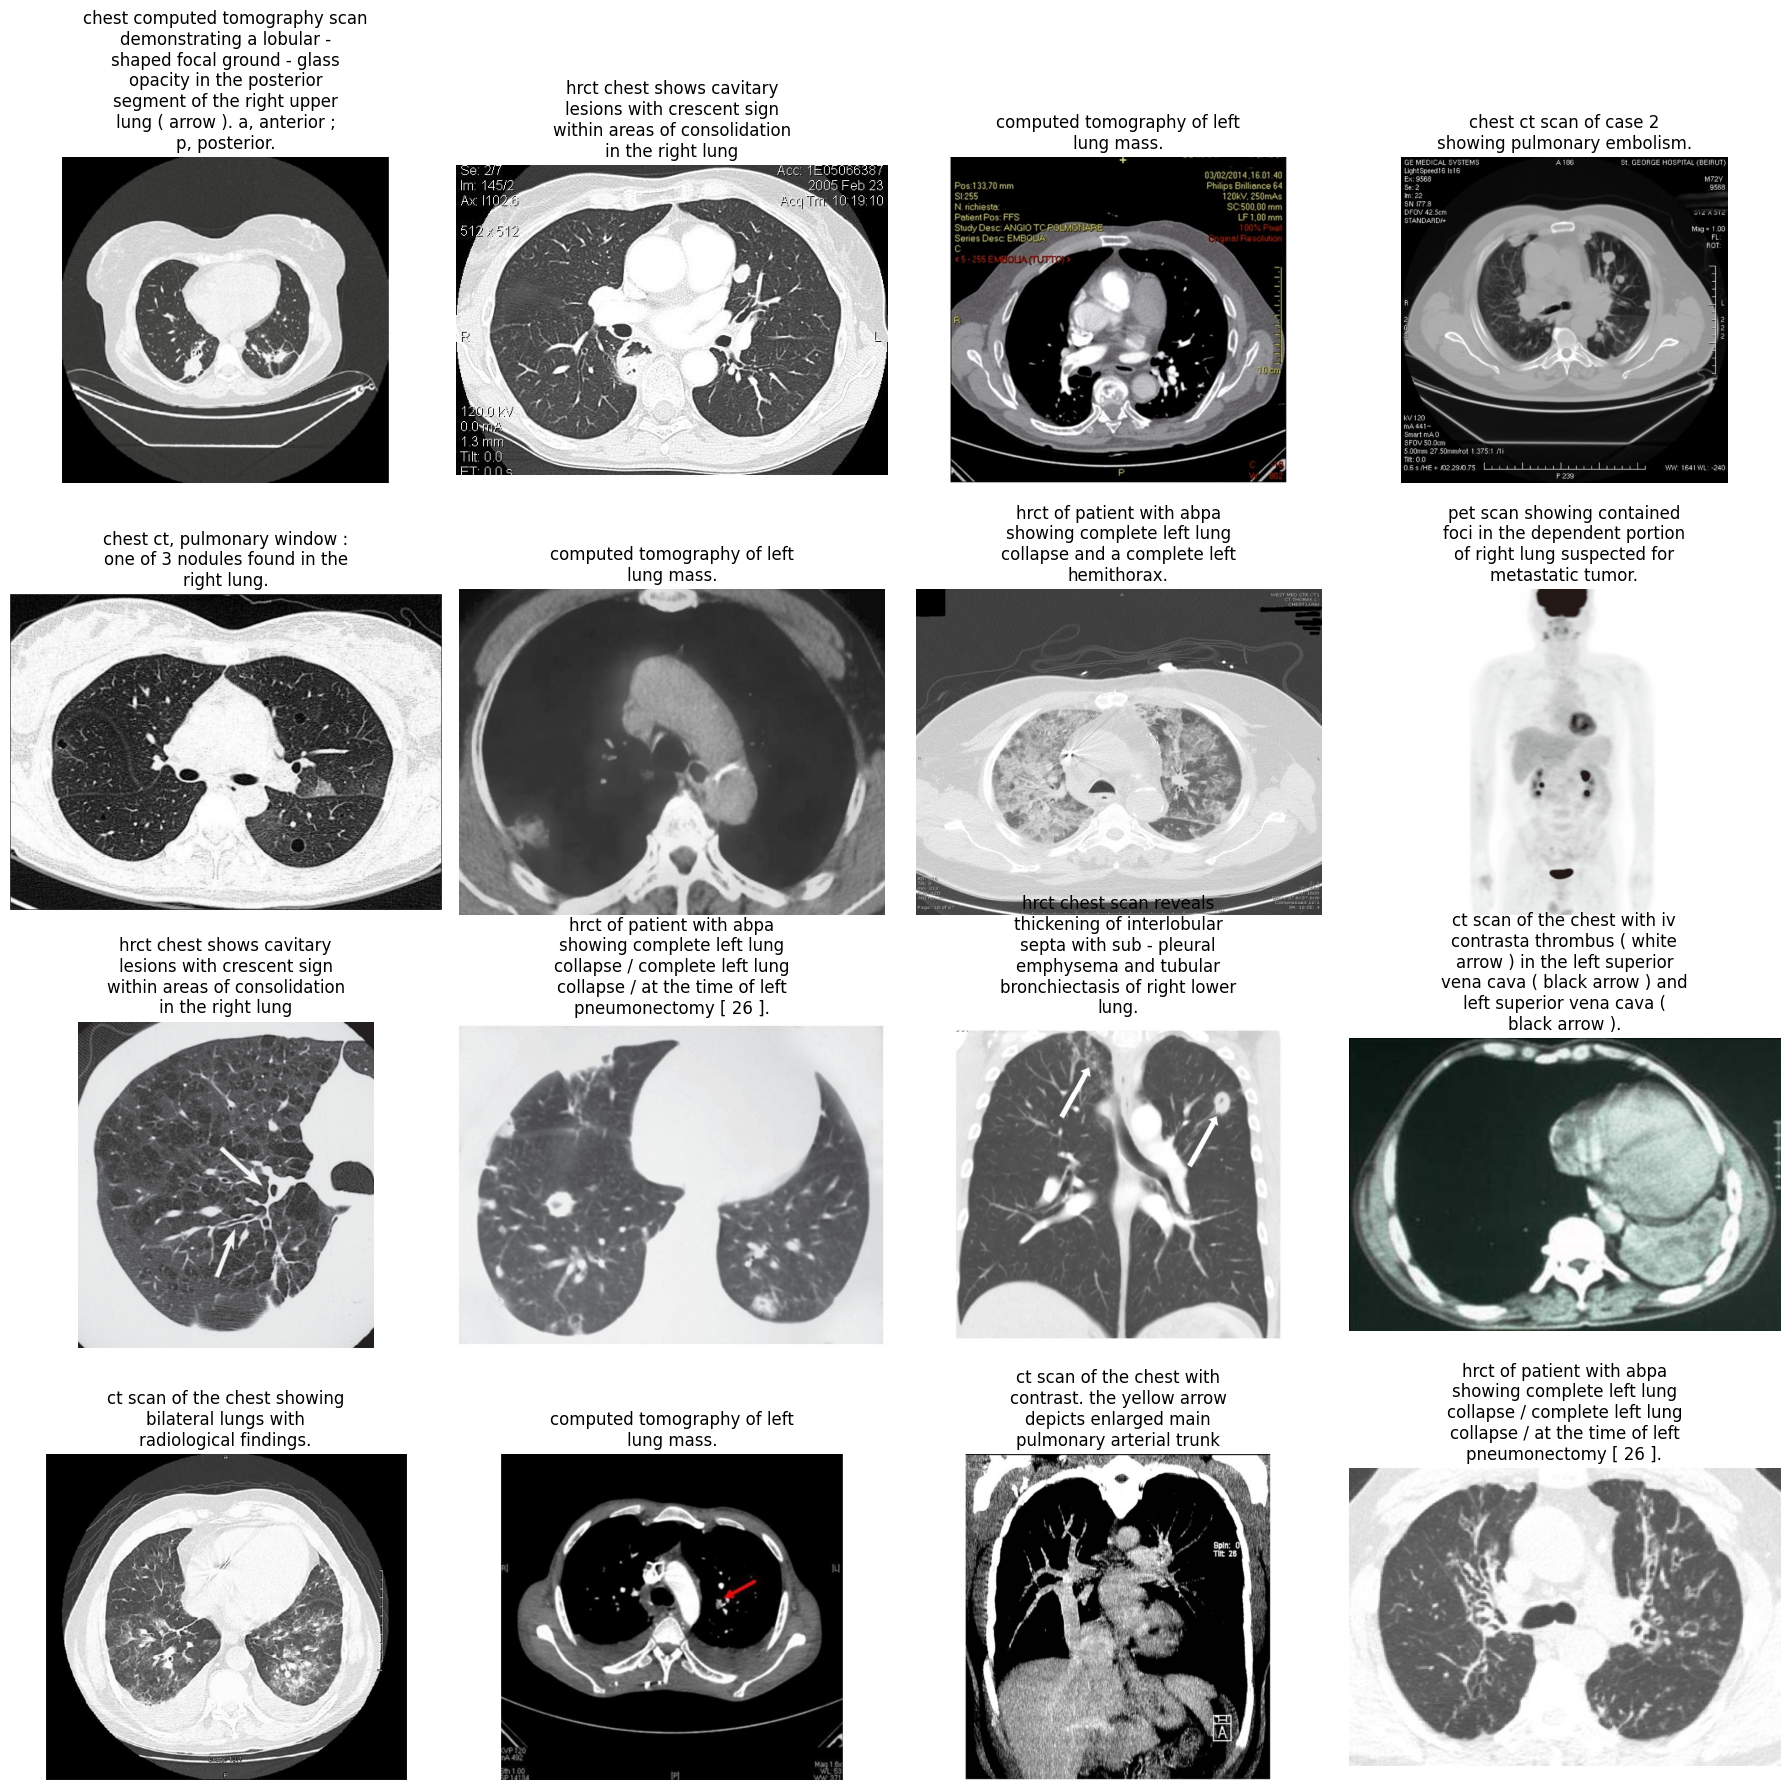

In [43]:
import textwrap
from PIL import Image
import matplotlib.pyplot as plt

# Predict 16 images of Test Data from trained model
fig = plt.figure(figsize=(18, 18))

for i, example in enumerate(test_dataset):
    img_path = example["image"]                         # path của ảnh
    image = Image.open(img_path).convert("RGB")         # load ảnh

    inputs = processor(images=image, return_tensors="pt").to(device)
    pixel_values = inputs.pixel_values

    generated_ids = model.generate(pixel_values=pixel_values, max_length=50)
    generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    wrapped_caption = textwrap.fill(generated_caption, width=30)

    fig.add_subplot(4, 4, i+1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(wrapped_caption)

    if i == 15:
        break

plt.tight_layout()
plt.show()

In [45]:
%pip install evaluate nltk pillow sacrebleu rouge_score

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 42.5 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 19.0.1
    Uninstalling pyarrow-19.0.1:
      Successfully uninstalled pyarrow-19.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pylibcudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow

In [46]:
print("\nBắt đầu đánh giá định lượng trên toàn bộ tập test...")

import evaluate
import nltk
from tqdm import tqdm
from PIL import Image

# 1. Load metrics
bleu_metric = evaluate.load("sacrebleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")

# 2. Cần thiết cho ROUGE và METEOR
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

all_predictions = []
all_references = []

# 3. Evaluate on test set
model.eval()

for item in tqdm(test_dataset, desc="Evaluating all test samples"):
    reference_text = item["text"]      # giữ nguyên
    img_path = item.get("image")

    try:
        image = Image.open(img_path).convert("RGB")  # mở ảnh

        # Chuẩn bị input và sinh văn bản dự đoán
        inputs = processor(images=image, return_tensors="pt").to(device)
        generated_ids = model.generate(**inputs, max_new_tokens=128)
        gen_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

        # Lưu kết quả
        all_predictions.append(gen_text)
        all_references.append(reference_text)

    except Exception as e:
        print("Error:", e)
        all_predictions.append("")
        all_references.append(reference_text)

# 4. Compute scores
print("\nĐang tính toán điểm số...")

try:
    bleu_score = bleu_metric.compute(
        predictions=all_predictions,
        references=[[r] for r in all_references]
    )

    rouge_score = rouge_metric.compute(
        predictions=all_predictions,
        references=all_references
    )

    meteor_score = meteor_metric.compute(
        predictions=all_predictions,
        references=all_references
    )

    print("\n===== Kết quả Đánh giá Định lượng =====")
    print(f"Tổng số mẫu: {len(all_predictions)}")
    print(f"BLEU: {bleu_score['score']:.4f}")
    print(f"ROUGE-L: {rouge_score['rougeL'] * 100:.2f}")
    print(f"METEOR: {meteor_score['meteor'] * 100:.2f}")
    print("========================================")
    print("Chi tiết ROUGE:", rouge_score)

except Exception as e:
    print(f"Lỗi khi tính toán độ đo: {e}")


Bắt đầu đánh giá định lượng trên toàn bộ tập test...


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
Evaluating all test samples: 100%|██████████| 155/155 [01:11<00:00,  2.17it/s]



Đang tính toán điểm số...

===== Kết quả Đánh giá Định lượng =====
Tổng số mẫu: 155
BLEU: 1.5951
ROUGE-L: 17.15
METEOR: 15.47
Chi tiết ROUGE: {'rouge1': 0.21002282596331973, 'rouge2': 0.04098791193039796, 'rougeL': 0.17152442377016644, 'rougeLsum': 0.1721860927790351}


In [35]:
import os
import shutil

# Đường dẫn folder model bạn đã lưu
save_path = "/kaggle/working/blip2_finetuned"

# Tên file zip output (sẽ nằm ở /kaggle/working/blip_model_final.zip)
output_filename = "blip_model_final"

# Nén folder
shutil.make_archive(output_filename, 'zip', save_path)

print(f"✅ Đã nén xong! File nằm tại: /kaggle/working/{output_filename}.zip")

✅ Đã nén xong! File nằm tại: /kaggle/working/blip_model_final.zip


In [36]:
from IPython.display import FileLink

# Hiển thị link tải
FileLink(r'blip_model_final.zip')

/kaggle/working/blip_model_final.zip